# Ejercicio K Nearest Neighbors (KNN)- Solución

Este es un ejercicio simple, parecido al que realizamos en clase...solo que con otro conjunto de datos. Solamente deben seguir las instrucciones abajo indicadas.

## Importar las Librerias

**Import pandas,seaborn, y las otras acostumbradas.**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Obtener los datos

**Lea el archivo 'Datos_Proyecto_KNN.csv' para que quede en un dataframe**


In [6]:
datos = pd.read_csv("Datos_Proyecto_KNN.csv", index_col=0)

**Verificar el encabezado del dataframe.**


In [7]:
datos.head()

,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
XVPM,,,,,,,,,,
1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


# EDA

Como estos datos son ficticios genere una gráfica de tipo 'pairplot'.

**Utilice seaborn para crear un 'pairplot' con los colores indicados por la columna TARGET CLASS.**


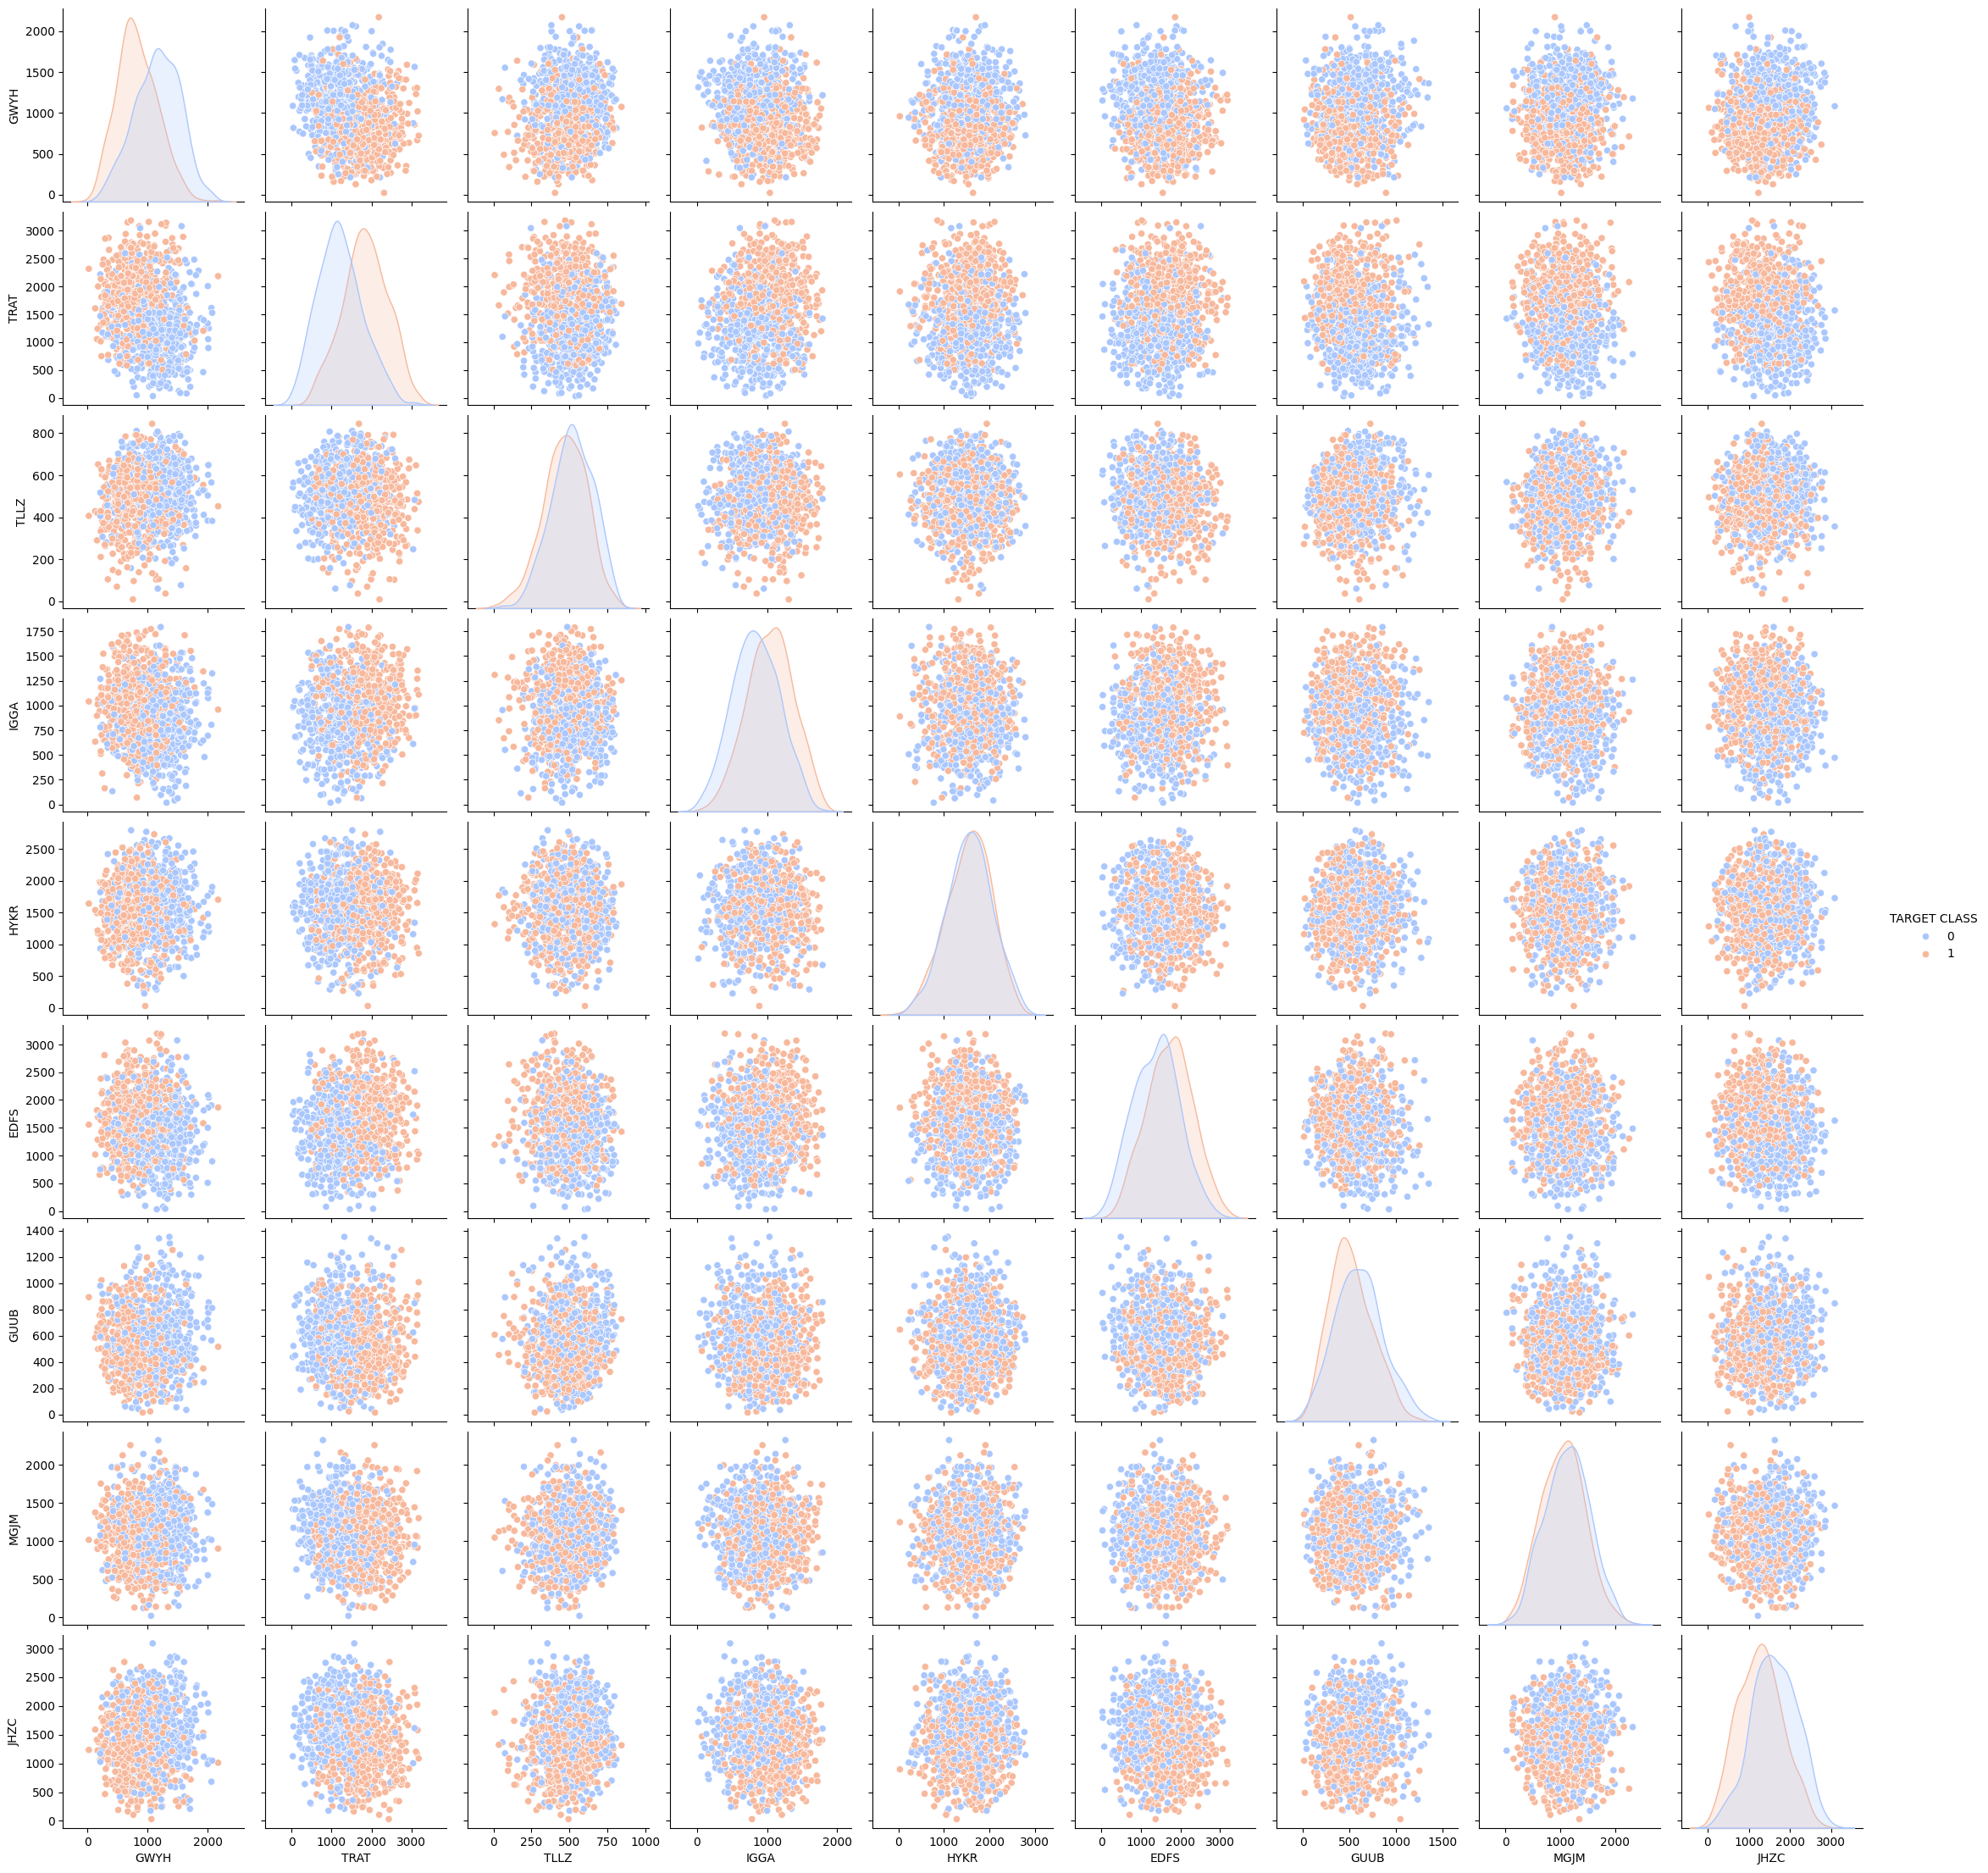

In [11]:
sns.pairplot(datos, hue="TARGET CLASS", palette="coolwarm")

plt.show()

# Estandarizar o normalizar las Variables

Es momento de estandarizar las variables.

**Importe StandardScaler de Scikit learn.**


In [9]:
from sklearn.preprocessing import StandardScaler

**Instancie un objeto de StandardScaler() que se llame escalador.**


In [12]:
scaler = StandardScaler()

**Aplique el escalador a las variables (features).**


In [ ]:
# Separar características (X) y objetivo (y)
X = datos.drop("TARGET CLASS", axis=1)
y = datos["TARGET CLASS"]

scaler.fit(X)

StandardScaler()

**Utilice el método .transform() para transformar las variables (features) a una versión normalizada.**


In [ ]:
# Usar transform() para transformar las variables a versión normalizada
X_normalizadas = scaler.transform(X)

**Convierta las variables normalizadas a un dataframe y verifique el encabezado de este dataframe para asegurar qur funcionó la normalización.**


In [ ]:
# Puedes verlo en forma de DataFrame (opcional pero recomendado)
X_normalizadas_df = pd.DataFrame(X_normalizadas, columns=X.columns)

# Mostrar los resultados
print(X_normalizadas_df.head())

       GWYH      TRAT      TLLZ      IGGA      HYKR      EDFS      GUUB  \
0 -0.443435  1.619808 -0.958255 -1.128481  0.138336  0.980493 -0.932794   
1 -1.056574  1.741918 -1.504220  0.640009  1.081552 -1.182663 -0.461864   
2 -0.436981  0.775793  0.213394 -0.053171  2.030872 -1.240707  1.149298   
3  0.191324 -1.433473 -0.100053 -1.507223 -1.753632 -1.183561 -0.888557   
4  0.820815 -0.904346  1.609015 -0.282065 -0.365099 -1.095644  0.391419   

       MGJM      JHZC  
0  1.008313 -1.069627  
1  0.258321 -1.041546  
2  2.184784  0.342811  
3  0.162310 -0.002793  
4 -1.365603  0.787762  


# División Entrenamiento - Prueba (Train - Test Split)

**Utilice train_test_split para separar sus datos en un conjunto de entrenamiento y otro de prueba.**


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_normalizadas, y, test_size=0.3, random_state=101
)

In [ ]:
# Verificar tamaños resultantes
print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")

Tamaño entrenamiento: (700, 9)
Tamaño prueba: (300, 9)


# Uso del KNN

**Importe KNeighborsClassifier de scikit learn.**


In [21]:
from sklearn.neighbors import KNeighborsClassifier

**Cree una instancia del modelo KNN con n_neighbors = 1**


In [22]:
knn = KNeighborsClassifier(n_neighbors=1)

**Ajuste este modelo de KNN con los datos de entrenamiento.**


In [24]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

# Predicciones y Evaluaciones

Evalúe su modelo KNN!


**Utilice el método predict para predecir valores utilizando su modelo KNN y el conjunto de datos de prueba X_test.**


In [25]:
pred = knn.predict(X_test)

**Cree una matriz de confusión así como un reporte de clasificación.**


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Matriz de confusión
matriz_confusion = confusion_matrix(y_test, pred)
print("Matriz de Confusión:")
print(matriz_confusion)

Matriz de Confusión:
[[105  47]
 [ 39 109]]


In [30]:
# Reporte de clasificación
reporte = classification_report(y_test, pred)
print("\nReporte de Clasificación:")
print(reporte)


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.73      0.69      0.71       152
           1       0.70      0.74      0.72       148

    accuracy                           0.71       300
   macro avg       0.71      0.71      0.71       300
weighted avg       0.71      0.71      0.71       300



# Selección de un valor para K

**Utilice el método de codo para seleccionar un buen valor de K!**

**Cree una iteración que entrene varios modelos KNN con diferentes valores de k. Lleve control de la tasa de error para cada uno de estos modelos con una lista. Vea el ejemplo realizado en clase si existe alguna confusión en este paso.**


In [64]:
# Importar librerías necesarias
import numpy as np

# Lista para almacenar la tasa de error
tasa_error = []

# Probar valores de K desde 1 hasta 40
k_values = range(1, 41)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    predicciones_k = knn.predict(X_test)
    tasa_error.append(np.mean(predicciones_k != y_test))  # Cálculo del error

**Ahora cree una gráfica de tasa-de-error vrs. k utilizando la información obtenida con la iteración.**


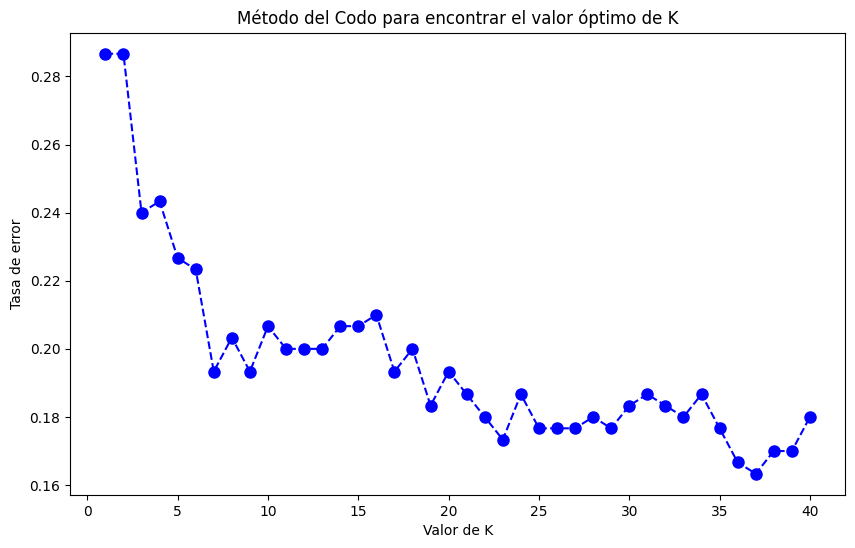

In [65]:
# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(k_values, tasa_error, marker="o", linestyle="dashed", color="b", markersize=8)
plt.xlabel("Valor de K")
plt.ylabel("Tasa de error")
plt.title("Método del Codo para encontrar el valor óptimo de K")
plt.show()

## Re-entrenar el modelo con el nuevo valor de K

**Vuelva a entrenar su modelo con el mejor valor de K (le queda a Ud decidir cuál quiere) y genere de nuevo la matriz de confusión y el reporte de clasificación.**


El valor óptimo de K usando 'convex' es: 3
El valor óptimo de K usando 'concave' es: 40


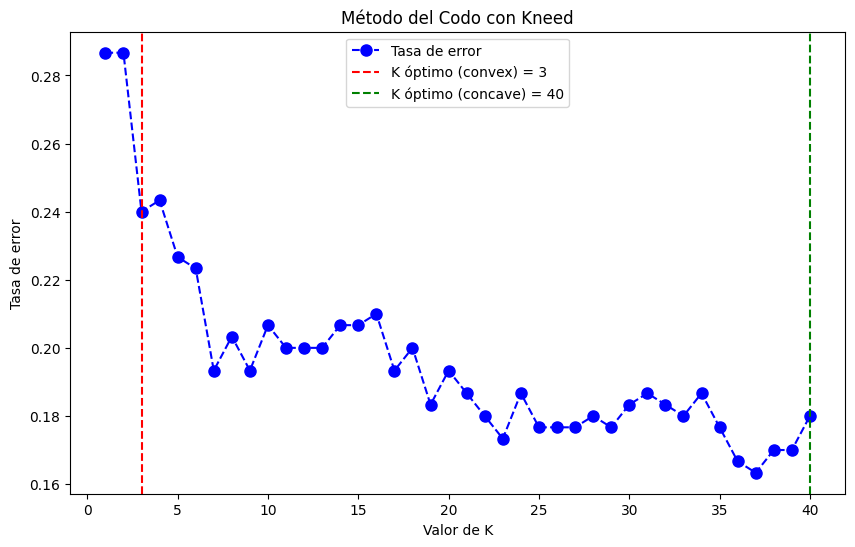

In [73]:
from kneed import KneeLocator

# Intentar con diferentes configuraciones
kneedle1 = KneeLocator(range(1, 41), tasa_error, curve="convex", direction="decreasing")
kneedle2 = KneeLocator(
    range(1, 41), tasa_error, curve="concave", direction="decreasing"
)

# Obtener los valores óptimos de K detectados
k_optimo1 = kneedle1.knee
k_optimo2 = kneedle2.knee

print(f"El valor óptimo de K usando 'convex' es: {k_optimo1}")
print(f"El valor óptimo de K usando 'concave' es: {k_optimo2}")

# Graficar ambos resultados
plt.figure(figsize=(10, 6))
plt.plot(
    k_values,
    tasa_error,
    marker="o",
    linestyle="dashed",
    color="b",
    markersize=8,
    label="Tasa de error",
)

# Marcar el punto de codo encontrado por cada método
plt.axvline(
    x=k_optimo1, color="r", linestyle="--", label=f"K óptimo (convex) = {k_optimo1}"
)
plt.axvline(
    x=k_optimo2, color="g", linestyle="--", label=f"K óptimo (concave) = {k_optimo2}"
)

plt.xlabel("Valor de K")
plt.ylabel("Tasa de error")
plt.title("Método del Codo con Kneed")
plt.legend()
plt.show()

In [76]:
# Elegir el mejor valor de K basado en la gráfica
k_optimo = 40  # Puedes cambiarlo según la interpretación de la gráfica

# Crear y entrenar el modelo KNN con el nuevo K
knn_optimo = KNeighborsClassifier(n_neighbors=k_optimo)
knn_optimo.fit(X_train, y_train)

# Hacer predicciones con el nuevo modelo
predicciones_optimas = knn_optimo.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report

# Matriz de confusión
matriz_confusion_optima = confusion_matrix(y_test, predicciones_optimas)
print("Matriz de Confusión:")
print(matriz_confusion_optima)

# Reporte de clasificación
reporte_optimo = classification_report(y_test, predicciones_optimas)
print("\nReporte de Clasificación:")
print(reporte_optimo)

Matriz de Confusión:
[[124  28]
 [ 26 122]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       152
           1       0.81      0.82      0.82       148

    accuracy                           0.82       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.82      0.82      0.82       300



# Excelente trabajo!
